In [ ]:
# Standard libraries
import os

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Typing utilities
from typing import Dict, Any, List, Optional


In [42]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [43]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

In [44]:
# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
df = df.set_index('SamplingOperations_code')
 
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'CodeSite_SamplingOperations', 'Date_SamplingOperation'])
df

TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      NaN      NaN   
S02000008_20200708                                    400      NaN      NaN   
S02000010_20070906                                    400      NaN      NaN   
S02000010_20090721                                    400      NaN      NaN   
S02000010_20110723                                    398      NaN      NaN   
...                                                   ...      ...      ...   
S06940940_20100708                                    438      NaN      NaN   
S06940940_20230623                                    408      NaN      NaN   
S06960950_20160629                                    401      NaN      NaN   
S06960950_20180719                                    416      NaN      NaN   
S06970900_20150601                                    432      NaN      NaN   

                         Achaf01    Achaf02  Achal01  Acham01  Achan01  \
SamplingOperations_code                                                  
S02000008_20170703           NaN        NaN      NaN      NaN      NaN   
S02000008_20200708           NaN        NaN      NaN      NaN      NaN   
S02000010_20070906           NaN        NaN      NaN      NaN      NaN   
S02000010_20090721           NaN        NaN      NaN      NaN      NaN   
S02000010_20110723           NaN        NaN      NaN      NaN      NaN   
...                          ...        ...      ...      ...      ...   
S06940940_20100708           NaN        NaN      NaN      NaN      NaN   
S06940940_20230623           NaN        NaN      NaN      NaN      NaN   
S06960950_20160629           NaN        NaN      NaN      NaN      NaN   
S06960950_20180719           NaN  19.230769      NaN      NaN      NaN   
S06970900_20150601           NaN        NaN      NaN      NaN      NaN   

                         Achat01   Achat02  Achat03  Achba01  Achbi01  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN       NaN      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN  6.944444      NaN      NaN      NaN   

                         Achbi02   Achbr01  Achca01  Achca02  Achca03  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN  2.283105      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN       NaN      NaN      NaN      NaN   

                         Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
SamplingOperations_code                              

# For each region

In [45]:
import cleandf

In [ ]:
# For all regions 1, 2, ..., 22
regiondfs = {}
for region in range(1, 23):
    print(f"Region: {region}")
    regiondf = df[df['HERlvl1Code'] == region]

    cleanregion = cleandf.IWANTMYXCLEAN(regiondf, thresh_high_missing=.99)
    regiondfs[region] = cleanregion

Region: 1
Dropped exact duplicate columns: ['Achac01', 'Achal01', 'Achca01', 'Achch01', 'Achcl01', 'Achco01', 'Achco03', 'Achcy01', 'Achde01', 'Achde02', 'Achdi01', 'Achdi02', 'Achel01', 'Achen01', 'Achex03', 'Achfl01', 'Achfr01', 'Achgr01', 'Achgr02', 'Achha01', 'Achhe01', 'Achhi01', 'Achho01', 'Achho02', 'Achim01', 'Achim02', 'Achim03', 'Achin01', 'Achin02', 'Achjo01', 'Achko01', 'Achkr01', 'Achkr03', 'Achkr04', 'Achku01', 'Achla01', 'Achla05', 'Achle01', 'Achle02', 'Achli02', 'Achli04', 'Achlo01', 'Achlu01', 'Achlu02', 'Achmo01', 'Achmo02', 'Achna01', 'Achna02', 'Achni01', 'Achno01', 'Achpa01', 'Achpe01', 'Achpe02', 'Achpl01', 'Achpo01', 'Achpr01', 'Achpr02', 'Achps01', 'Achps02', 'Achps03', 'Achpu01', 'Achro01', 'Achro03', 'Achru02', 'Achsc01', 'Achse01', 'Achse02', 'Achsi01', 'Achst01', 'Achst02', 'Achst04', 'Achsu02', 'Achsu04', 'Achtu01', 'Achzi01', 'Actde01', 'Actno01', 'Actro01', 'Actse01', 'Actsp01', 'Actsu01', 'Actvu01', 'Adlaq01', 'Adlbr01', 'Adlmu01', 'Adlmu02', 'Adlpa01',

In [59]:
regiondfs[1]

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achca04,Achco04,Achcr01,Achde03,Achdr01,Acheu01,Achho03,Achla02,Achli03,Achmi02,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Adlmi01,Ampin01,Ampin02,Amppe02,Calae01,Calba01,Cocdi01,Coceu01,Cocli01,Cocpe01,Cocpl01,Cycme02,Cycps01,Cymaf02,Cymco01,Cymex01,Cymex02,Cymmi01,Cymsi01,Cymve01,Dente01,Diaeh01,Diame01,Diavu01,Didge01,Encsu03,Exiva01,Fraca04,Fragr01,Frapa01,Frape01,Frare01,Fraru01,Frave01,Geiac01,Goman05,Gomca01,Gomca02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi01,Gommi02,Gommi03,Gommi05,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Melva01,Navan05,Navar02,Navca07,Navca08,Navcr05,Navcr09,Navcr10,Navex02,Navgr01,Navla04,Navoc01,Navpe05,Navpe06,Navre04,Navsa03,Navsu03,Navsu07,Nitam01,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitpa01,Nitpa02,Nitre01,Nitso01,Nitso04,Nupla01,Plala02,Plesc01,Psabi01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,682.500000,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,765.000000,15.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,2.5,NaN,NaN,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,2.500000,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,NaN,NaN,NaN,NaN,NaN,20.0,1.0,High,5.000000,1
S05168100_20090625,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,637.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.5,NaN,NaN,NaN,NaN,NaN,NaN,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,Good,High,High,High,High,High,High,High,High,High,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Good,Good,Good,Moderate,Moderate,Moderate,20.0,1.0,High,22.500000,1
S05168100_20100629

In [ ]:
class MultiRegionRFClassifier:
    """
    One RandomForestClassifier per region.
    Train on rows with non-NaN target; predict rows with NaN target.
    Uses OOB accuracy as a quality proxy.
    """

    def __init__(self, xcleans: Dict[Any, pd.DataFrame], random_state: int = 42):
        self.xcleans = xcleans
        self.random_state = random_state
        self.results: Dict[Any, Dict[str, Any]] = {}
        self.target_column: Optional[str] = None

    # ---------- helpers ----------
    @staticmethod
    def _resolve_col(df: pd.DataFrame, name: str) -> str:
        if name in df.columns:
            return name
        low = name.lower()
        for c in df.columns:
            if c.lower() == low:
                return c
        raise KeyError(f"Target column '{name}' not found (case-insensitive).")

    @staticmethod
    def _build_preprocessor(X: pd.DataFrame) -> tuple[ColumnTransformer, List[str], List[str]]:
        num_cols = X.select_dtypes(include=["number"]).columns.tolist()
        cat_cols = [c for c in X.columns if c not in num_cols]
        pre = ColumnTransformer(
            transformers=[
                ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
                ("cat", Pipeline([
                    ("imp", SimpleImputer(strategy="constant", fill_value="None")),
                    # dense output to map importances -> names easily
                    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]), cat_cols),
            ],
            remainder="drop",
        )
        return pre, num_cols, cat_cols

    @staticmethod
    def _feature_names_from_pre(pre: ColumnTransformer, num_cols: List[str], cat_cols: List[str]) -> List[str]:
        names: List[str] = []
        if num_cols:
            names.extend(num_cols)
        if cat_cols and "cat" in pre.named_transformers_:
            ohe = pre.named_transformers_["cat"].named_steps["ohe"]
            names.extend(ohe.get_feature_names_out(cat_cols).tolist())
        return names

    # ---------- main ----------
    def process_missing_class(
        self,
        target_column: str = "IBD_EQR_Status",  # accepts 'IBD_EQR_STATUS' too
        n_estimators: int = 500,
        max_depth: Optional[int] = None,
        min_samples_leaf: int = 1,
        n_jobs: int = -1,
        class_weight: Optional[str] = "balanced",
        verbose: bool = True,
    ):
        self.results.clear()
        self.target_column = target_column

        for key, Xclean in self.xcleans.items():
            try:
                y_col = self._resolve_col(Xclean, target_column)
            except KeyError:
                if verbose: print(f"[skip {key}] missing target '{target_column}'")
                continue
            if len(Xclean) < 5:
                if verbose: print(f"[skip {key}] too few rows: {len(Xclean)}")
                continue

            y = Xclean[y_col]

            # Drop target and obvious leakage columns if present
            to_drop = {y_col, "IBD", "IBD_EQR", "IBD_EQR_Status"}
            X = Xclean.drop(columns=[c for c in to_drop if c in Xclean.columns], errors="ignore")

            mask_tr = y.notna()
            mask_te = ~mask_tr
            n_tr, n_te = int(mask_tr.sum()), int(mask_te.sum())
            if n_tr == 0:
                if verbose: print(f"[skip {key}] no labeled rows")
                continue

            pre, num_cols, cat_cols = self._build_preprocessor(X)

            clf = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=self.random_state,
                n_jobs=n_jobs,
                class_weight=class_weight,
                bootstrap=True,
                oob_score=True,   # OOB accuracy proxy
            )
            pipe = Pipeline([("pre", pre), ("model", clf)])

            X_tr, y_tr = X.loc[mask_tr], y.loc[mask_tr]
            pipe.fit(X_tr, y_tr)

            # Train predictions (for diagnostics, not evaluation)
            yhat_tr = pd.Series(pipe.predict(X_tr), index=y_tr.index, name="yhat_tr")

            # Test predictions
            if n_te:
                X_te = X.loc[mask_te]
                yhat_te = pd.Series(pipe.predict(X_te), index=X_te.index, name="yhat_te")
                # Probabilities per class on the missing rows
                proba_te = pipe.predict_proba(X_te)
                classes = pipe.named_steps["model"].classes_
                proba_te_df = pd.DataFrame(proba_te, index=X_te.index, columns=[f"proba_{c}" for c in classes])
            else:
                X_te = X.iloc[0:0]
                yhat_te = pd.Series(dtype=object, name="yhat_te")
                classes = pipe.named_steps["model"].classes_
                proba_te_df = pd.DataFrame(columns=[f"proba_{c}" for c in classes]).astype(float)

            # OOB diagnostics
            model = pipe.named_steps["model"]
            oob_acc = getattr(model, "oob_score_", None)
            # Map OOB decision function to indices of y_tr
            if hasattr(model, "oob_decision_function_") and model.oob_decision_function_ is not None:
                oob_df = pd.DataFrame(model.oob_decision_function_, index=y_tr.index, columns=[f"oob_proba_{c}" for c in model.classes_])
                oob_pred = pd.Series(model.classes_[np.argmax(model.oob_decision_function_, axis=1)],
                                     index=y_tr.index, name="oob_pred")
                oob_cm = pd.DataFrame(
                    confusion_matrix(y_tr, oob_pred, labels=model.classes_),
                    index=[f"true_{c}" for c in model.classes_],
                    columns=[f"pred_{c}" for c in model.classes_],
                )
            else:
                oob_df = pd.DataFrame(index=y_tr.index)
                oob_pred = pd.Series(index=y_tr.index, dtype=object, name="oob_pred")
                oob_cm = pd.DataFrame()

            # Feature importances
            pre_fitted = pipe.named_steps["pre"]
            feat_names = self._feature_names_from_pre(pre_fitted, num_cols, cat_cols)
            fi = pd.Series(model.feature_importances_, index=feat_names).sort_values(ascending=False)

            # Filled target
            y_filled = y.copy()
            if n_te:
                y_filled.loc[mask_te] = yhat_te.values

            # Store
            self.results[key] = {
                "model": pipe,
                "classes_": classes,
                "oob_accuracy": oob_acc,
                "oob_proba": oob_df,
                "oob_pred": oob_pred,
                "oob_confusion": oob_cm,
                "n_train": n_tr,
                "n_infer": n_te,
                "y_tr": y_tr,
                "yhat_tr": yhat_tr,
                "X_te_index": X_te.index,
                "yhat_te": yhat_te,
                "proba_te": proba_te_df,   # only for missing rows
                "y_filled": y_filled,
                "feature_importances": fi,
                "columns": {"num": num_cols, "cat": cat_cols},
            }
            if verbose:
                acc = "NA" if oob_acc is None else f"{oob_acc:.3f}"
                print(f"[done {key}] train={n_tr} infer={n_te} oob_acc={acc}")

    # ---------- convenience ----------
    def infer_table(self, key: Any) -> pd.DataFrame:
        """Row-aligned table: y_true (train), yhat_tr, yhat_te, y_filled, and test probs."""
        r = self.results[key]
        idx = self.xcleans[key].index
        out = pd.DataFrame(index=idx)
        out["y_true"] = r["y_tr"]              # NaN on unlabeled rows
        out["yhat_tr"] = r["yhat_tr"]
        out["yhat_te"] = r["yhat_te"]
        out["y_filled"] = r["y_filled"]
        # attach probabilities only on test rows
        out = out.join(r["proba_te"], how="left")
        return out

    def all_inferred(self) -> pd.DataFrame:
        frames = []
        for k, r in self.results.items():
            df = self.infer_table(k).reset_index().rename(columns={"index": "row_id"})
            df.insert(0, "region", k)
            frames.append(df)
        return pd.concat(frames, ignore_index=True)

    def filled_dataframe(self, key: Any) -> pd.DataFrame:
        if self.target_column is None:
            raise RuntimeError("Run process_missing_class first.")
        df = self.xcleans[key].copy()
        col = self._resolve_col(df, self.target_column)
        df[col] = self.results[key]["y_filled"]
        return df

    def top_features(self, key: Any, k: int = 20) -> pd.DataFrame:
        fi = self.results[key]["feature_importances"]
        return fi.head(k).reset_index().rename(columns={"index": "feature", 0: "importance"})

    def plot_oob_confusion(self, key: Any):
        cm = self.results[key]["oob_confusion"]
        if cm.empty:
            print("No OOB confusion matrix available.")
            return
        plt.figure(figsize=(5, 4))
        plt.imshow(cm.values, interpolation="nearest")
        plt.xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
        plt.yticks(range(len(cm.index)), cm.index)
        plt.title(f"OOB confusion — region {key}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

In [63]:
mrclf = MultiRegionRFClassifier(regiondfs, random_state=42)
mrclf.process_missing_class(target_column="IBD_EQR_STATUS", n_estimators=500, n_jobs=-1)

[done 1] train=1313 infer=172 oob_acc=0.819
[done 2] train=308 infer=44 oob_acc=0.906
[done 3] train=4430 infer=566 oob_acc=0.726
[done 4] train=494 infer=102 oob_acc=0.662
[done 5] train=2069 infer=244 oob_acc=0.798
[done 6] train=1898 infer=236 oob_acc=0.783
[done 7] train=466 infer=58 oob_acc=0.839
[done 8] train=469 infer=79 oob_acc=0.783
[done 9] train=9136 infer=1118 oob_acc=0.819
[done 10] train=3389 infer=537 oob_acc=0.808
[done 11] train=1141 infer=148 oob_acc=0.809
[done 12] train=4188 infer=489 oob_acc=0.792
[done 13] train=888 infer=115 oob_acc=0.720
[done 14] train=6916 infer=826 oob_acc=0.806
[done 15] train=1099 infer=124 oob_acc=0.748
[done 16] train=331 infer=48 oob_acc=0.764
[done 17] train=716 infer=87 oob_acc=0.746
[done 18] train=977 infer=187 oob_acc=0.788
[done 19] train=440 infer=60 oob_acc=0.843
[done 20] train=448 infer=60 oob_acc=0.748
[done 21] train=2332 infer=331 oob_acc=0.706
[done 22] train=120 infer=32 oob_acc=0.692


In [ ]:
# TRAIN ON 500 FORESTS 95% not missing 
# [done 1] train=1313 infer=172 oob_acc=0.816
# [done 2] train=308 infer=44 oob_acc=0.909
# [done 3] train=4430 infer=566 oob_acc=0.735
# [done 4] train=494 infer=102 oob_acc=0.678
# [done 5] train=2069 infer=244 oob_acc=0.800
# [done 6] train=1898 infer=236 oob_acc=0.793
# [done 7] train=466 infer=58 oob_acc=0.841
# [done 8] train=469 infer=79 oob_acc=0.787
# [done 9] train=9136 infer=1118 oob_acc=0.820
# [done 10] train=3389 infer=537 oob_acc=0.811
# [done 11] train=1141 infer=148 oob_acc=0.812
# [done 12] train=4188 infer=489 oob_acc=0.792
# [done 13] train=888 infer=115 oob_acc=0.732
# [done 14] train=6916 infer=826 oob_acc=0.811
# [done 15] train=1099 infer=124 oob_acc=0.758
# [done 16] train=331 infer=48 oob_acc=0.785
# [done 17] train=716 infer=87 oob_acc=0.742
# [done 18] train=977 infer=187 oob_acc=0.795
# [done 19] train=440 infer=60 oob_acc=0.830
# [done 20] train=448 infer=60 oob_acc=0.759
# [done 21] train=2332 infer=331 oob_acc=0.719
# [done 22] train=120 infer=32 oob_acc=0.683


# # TRAIN ON 666 FORESTS 95% not missing
# [done 1] train=1313 infer=172 oob_acc=0.813
# [done 2] train=308 infer=44 oob_acc=0.906
# [done 3] train=4430 infer=566 oob_acc=0.738
# [done 4] train=494 infer=102 oob_acc=0.680
# [done 5] train=2069 infer=244 oob_acc=0.800
# [done 6] train=1898 infer=236 oob_acc=0.793
# [done 7] train=466 infer=58 oob_acc=0.845
# [done 8] train=469 infer=79 oob_acc=0.793
# [done 9] train=9136 infer=1118 oob_acc=0.821
# [done 10] train=3389 infer=537 oob_acc=0.814
# [done 11] train=1141 infer=148 oob_acc=0.809
# [done 12] train=4188 infer=489 oob_acc=0.790
# [done 13] train=888 infer=115 oob_acc=0.731
# [done 14] train=6916 infer=826 oob_acc=0.808
# [done 15] train=1099 infer=124 oob_acc=0.754
# [done 16] train=331 infer=48 oob_acc=0.776
# [done 17] train=716 infer=87 oob_acc=0.750
# [done 18] train=977 infer=187 oob_acc=0.793
# [done 19] train=440 infer=60 oob_acc=0.836
# [done 20] train=448 infer=60 oob_acc=0.763
# [done 21] train=2332 infer=331 oob_acc=0.722
# [done 22] train=120 infer=32 oob_acc=0.667

# ... it does not improve 


# RANDOM FOREST CL
# lets try with 99% not missing

# TRAIN ON 500 FORESTS 99% not missing
# [done 1] train=1313 infer=172 oob_acc=0.819
# [done 2] train=308 infer=44 oob_acc=0.906
# [done 3] train=4430 infer=566 oob_acc=0.726
# [done 4] train=494 infer=102 oob_acc=0.662
# [done 5] train=2069 infer=244 oob_acc=0.798
# [done 6] train=1898 infer=236 oob_acc=0.783
# [done 7] train=466 infer=58 oob_acc=0.839
# [done 8] train=469 infer=79 oob_acc=0.783
# [done 9] train=9136 infer=1118 oob_acc=0.819
# [done 10] train=3389 infer=537 oob_acc=0.808
# [done 11] train=1141 infer=148 oob_acc=0.809
# [done 12] train=4188 infer=489 oob_acc=0.792
# [done 13] train=888 infer=115 oob_acc=0.720
# [done 14] train=6916 infer=826 oob_acc=0.806
# [done 15] train=1099 infer=124 oob_acc=0.748
# [done 16] train=331 infer=48 oob_acc=0.764
# [done 17] train=716 infer=87 oob_acc=0.746
# [done 18] train=977 infer=187 oob_acc=0.788
# [done 19] train=440 infer=60 oob_acc=0.843
# [done 20] train=448 infer=60 oob_acc=0.748
# [done 21] train=2332 infer=331 oob_acc=0.706
# [done 22] train=120 infer=32 oob_acc=0.692

# TRAIN ON 300 FORESTS 99% not missing
# [done 1] train=1313 infer=172 oob_acc=0.815
# [done 2] train=308 infer=44 oob_acc=0.906
# [done 3] train=4430 infer=566 oob_acc=0.724
# [done 4] train=494 infer=102 oob_acc=0.656
# [done 5] train=2069 infer=244 oob_acc=0.801
# [done 6] train=1898 infer=236 oob_acc=0.776
# [done 7] train=466 infer=58 oob_acc=0.841
# [done 8] train=469 infer=79 oob_acc=0.785
# [done 9] train=9136 infer=1118 oob_acc=0.817
# [done 10] train=3389 infer=537 oob_acc=0.806
# [done 11] train=1141 infer=148 oob_acc=0.798
# [done 12] train=4188 infer=489 oob_acc=0.790
# [done 13] train=888 infer=115 oob_acc=0.731
# [done 14] train=6916 infer=826 oob_acc=0.804
# [done 15] train=1099 infer=124 oob_acc=0.742
# [done 16] train=331 infer=48 oob_acc=0.758
# [done 17] train=716 infer=87 oob_acc=0.739
# [done 18] train=977 infer=187 oob_acc=0.785
# [done 19] train=440 infer=60 oob_acc=0.839
# [done 20] train=448 infer=60 oob_acc=0.754
# [done 21] train=2332 infer=331 oob_acc=0.712
# [done 22] train=120 infer=32 oob_acc=0.667

In [30]:
tbl1 = mrclf.infer_table(1)
tbl1

,y_true,yhat_tr,yhat_te,y_filled,proba_Bad,proba_Good,proba_High,proba_Moderate,proba_Poor
SamplingOperations_code,,,,,,,,,
S05168100_20070809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20080806,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20090625,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20100629,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20110809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
S06175540_20150728,NaN,NaN,High,High,0.000000,0.090090,0.909910,0.000000,0.000000
S06175600_20170904,NaN,NaN,High,High,0.000000,0.205706,0.746246,0.045045,0.003003
S06175600_20180926,NaN,NaN,High,High,0.000000,0.399399,0.552553,0.043544,0.004505


In [31]:
df1_filled = mrclf.filled_dataframe(1)
df1_filled

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achde03,Acheu01,Achho03,Achla02,Achli03,Achmi02,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampin02,Amppe02,Calae01,Coceu01,Cocli01,Cocpe01,Cocpl01,Cymco01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diaeh01,Diame01,Diavu01,Exiva01,Fragr01,Frape01,Geiac01,Goman05,Gomel01,Gomex01,Gomin06,Gommi01,Gommi05,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Melva01,Navan05,Navar02,Navca07,Navcr05,Navcr09,Navgr01,Navpe05,Navre04,Navsa03,Navsu03,Navsu07,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitpa01,Nitpa02,Nitso01,Nitso04,Plala02,Reisi01,Reiun01,Rhoab01,Selni01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,80.000000,682.500000,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,5.0,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.5,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,25.000000,765.000000,15.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,2.500000,10.000000,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,2.500000,2.5,NaN,NaN,NaN,NaN,7.5,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,NaN,NaN,NaN,NaN,NaN,20.0,1.0,High,7.500000,1
S05168100_20090625,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,637.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.5,NaN,NaN,NaN,NaN,12.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,Good,High,High,High,High,High,High,High,High,High,Moderate,Moderate,Moderate,Bad,Bad,Bad,High,High,High,Good,Good,Good,Moderate,Moderate,Moderate,20.0,1.0,High,22.500000,1
S05168100_20100629,414,NaN,24.154589,NaN,NaN,NaN,NaN,NaN,36.231884,826.086957,NaN,NaN,38.647343,NaN,NaN,NaN,NaN,NaN,NaN,7.246377,NaN,NaN,NaN,NaN,4.830918,33.816425,NaN,NaN,NaN,NaN,NaN,NaN,9.661836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415459,NaN,NaN,4.830918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.830918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.415459,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,NaN,NaN,High,NaN,NaN,High,NaN,NaN,High,NaN,NaN,Moderate,NaN,NaN,Bad,NaN,NaN,High,NaN,NaN,Moderate,NaN,NaN,Poor,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20110809,400,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,90.000000,692.500000,22.5,NaN,22.500000,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,7.500000,22.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,N

In [32]:
all_cls = mrclf.all_inferred()
all_cls

,region,SamplingOperations_code,y_true,yhat_tr,yhat_te,y_filled,proba_Bad,proba_Good,proba_High,proba_Moderate,proba_Poor
0,1,S05168100_20070809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
1,1,S05168100_20080806,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
2,1,S05168100_20090625,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
3,1,S05168100_20100629,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
4,1,S05168100_20110809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
49226,22,S03128500_20120723,NaN,NaN,Moderate,Moderate,NaN,0.334835,0.042042,0.623123,0.000000
49227,22,S03128640_20130718,NaN,NaN,Moderate,Moderate,NaN,0.402402,0.084084,0.448949,0.064565
49228,22,S03128640_20181011,NaN,NaN,Moderate,Moderate,NaN,0.418919,0.070571,0.439940,0.070571
49229,22,S03128732_20210817,NaN,NaN,Good,Good,NaN,0.483483,0.090090,0.366366,0.060060


In [33]:
mrclf.results[1]["oob_accuracy"]

0.8126428027418127

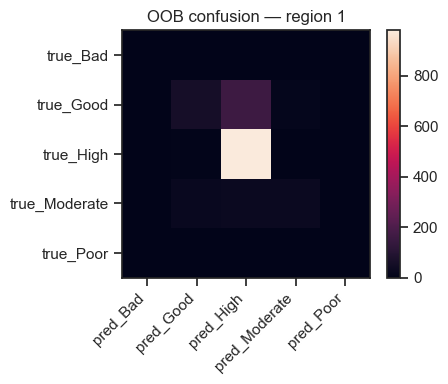

In [34]:
mrclf.plot_oob_confusion(1)

In [35]:
mrclf.top_features(1, k=15)

,feature,importance
0,Achpy01,0.072378
1,Navpe05,0.034576
2,Selni01,0.026488
3,Achmi02,0.023854
4,Navcr09,0.023206
5,Cocli01,0.022571
6,Uncommon_Taxons,0.021455
7,Nitpa02,0.019113
8,Achde03,0.018122
9,Coceu01,0.017474


# Get predictions

In [64]:
all_cls = all_cls.set_index('SamplingOperations_code')
yhat_te = all_cls['yhat_te'][all_cls['yhat_te'].notna()]
yhat_te = yhat_te.to_frame()
yhat_te.to_csv('IBD_EQR_Status_predictions_5663.csv')
yhat_te

,yhat_te
SamplingOperations_code,
S05169000_20130911,High
S05169000_20200819,High
S05172000_20210813,High
S05172050_20210824,High
S05172350_20120827,High
...,...
S03128500_20120723,Moderate
S03128640_20130718,Moderate
S03128640_20181011,Moderate


lol lol lol? nos deberia dar error?

al final toma en cuenta solo las 5063 predicciones que pide, no se que le hace a las otras 600